# Diabetes Prediction Project

## 1) Introduction:

This project aims to predict the chance of someone getting diabetes based on different health-related features. We explore the influence of various features on the diabetes target column within the given dataset. The motivation for this project stems from the high prevalence of diabetes and the potential for a data-driven analytical approach to aid in early detection, hypothesis generation regarding the disease, or even contribute to its cure. A significant challenge tackled in this study is the class imbalance, where the number of non-diabetic cases greatly outweighs diabetic cases. This real-world scenario demands careful evaluation metrics and resampling strategies.

## 2) Dataset Description:

The goal is to explore whether a person is diabetic (diabetes = 1) or not (diabetes = 0) from the dataset. The target column is 'diabetes', making this a classification problem with two classes: 0 (non-diabetic) and 1 (diabetic). The dataset contains the following 9 input features:

*   **gender** (categorical)
*   **age** (quantitative)
*   **hypertension** (binary/categorical)
*   **heart_disease** (binary/categorical)
*   **smoking_history** (categorical)
*   **bmi** (quantitative)
*   **HbA1c_level** (quantitative)
*   **blood_glucose_level** (quantitative)
*   **diabetes** (target variable - binary class)

After initial cleaning (removing the missing target labels), the dataset has around 90,000+ entries, with roughly 80,000 non-diabetic and <10,000 diabetic samples.

This indicates an imbalanced dataset. If models are trained without addressing this imbalance, they might tend to predict the majority class (non-diabetic) frequently, leading to high accuracy but poor performance in detecting actual diabetes cases. Therefore, techniques like SMOTE (Synthetic Minority Over-sampling Technique) and using models with `class_weight='balanced'` were employed.

## 3) Methodology:

The project followed these steps:

*   **Data Loading:** The diabetes dataset was loaded into a pandas DataFrame.
*   **Exploratory Data Analysis (EDA):** Initial exploration included viewing the head of the dataset, checking columns and shape, visualizing the class distribution of the target variable, and examining the correlation between features and the target.
*   **Data Preprocessing:**
    *   Rows with missing target values were removed.
    *   Missing values in numerical columns ('age', 'bmi', 'HbA1c_level', 'blood_glucose_level') were imputed using the median.
    *   Missing values in categorical columns ('smoking_history', 'gender', 'hypertension', 'heart_disease') were filled with default values or 0.
    *   Categorical features were encoded: 'gender' was mapped to numerical values, and 'smoking_history' was one-hot encoded.
    *   Features were scaled using `StandardScaler`.
*   **Handling Class Imbalance:** SMOTE was applied to the training data to oversample the minority class (diabetic cases).
*   **Model Training:** Several classification models were trained on the processed data:
    *   Logistic Regression (with `class_weight='balanced'`)
    *   K-Nearest Neighbors (KNN)
    *   Decision Tree
    *   Naive Bayes
    *   Neural Network (MLP Classifier)
*   **Model Evaluation:** The trained models were evaluated using various metrics suitable for imbalanced datasets, including:
    *   Classification Report (precision, recall, f1-score)
    *   Confusion Matrix
    *   ROC Curve and AUC Score
    *   Accuracy Score
    *   F1 Score
    *   ROC AUC Score

## 4) Results and Discussion:

The models were evaluated based on their performance on the test set. The classification reports, confusion matrices, and ROC curves provided insights into how well each model performed, particularly in identifying the minority class (diabetic cases).

[Include a summary of the key findings from the model evaluation, e.g., which models performed best on recall or F1-score for the diabetic class, and any observations about the impact of SMOTE.]

The correlation analysis and feature importance from Logistic Regression highlighted the most influential features in predicting diabetes.

[Include a summary of the most important features identified.]

## 5) Conclusion:

This project demonstrated an approach to predicting diabetes using a dataset with class imbalance. By applying appropriate preprocessing and handling the imbalance, we were able to train and evaluate several classification models. The results provide a basis for understanding the factors influencing diabetes and the potential for using machine learning in its prediction. Further work could involve exploring more advanced modeling techniques, feature engineering, or hyperparameter tuning to improve performance.

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    classification_report, accuracy_score,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve
)
!pip install imbalanced-learn
from imblearn.over_sampling import SMOTE


In [ ]:
from google.colab import files
dataset= files.upload()

Saving diabetes_dataset.xlsx to diabetes_dataset.xlsx


In [ ]:
df = pd.read_excel('diabetes_dataset.xlsx')

In [ ]:
print(df.head())
print("Columns:", list(df.columns))
print("Shape:", df.shape)


   gender   age  hypertension  heart_disease smoking_history    bmi  \
0  Female  80.0           0.0            1.0           never  25.19   
1  Female   NaN           0.0            0.0         No Info  27.32   
2    Male  28.0           0.0            0.0           never  27.32   
3  Female  36.0           0.0            0.0             NaN  23.45   
4    Male  76.0           1.0            1.0         current  20.14   

   HbA1c_level  blood_glucose_level  diabetes  
0          6.6                140.0       0.0  
1          6.6                 80.0       0.0  
2          NaN                158.0       0.0  
3          5.0                155.0       0.0  
4          4.8                  NaN       NaN  
Columns: ['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history', 'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes']
Shape: (100000, 9)


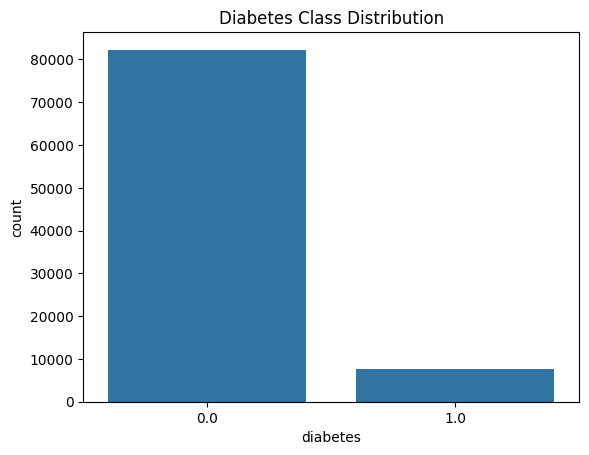

In [ ]:
sns.countplot(data=df, x='diabetes')
plt.title('Diabetes Class Distribution')
plt.show()

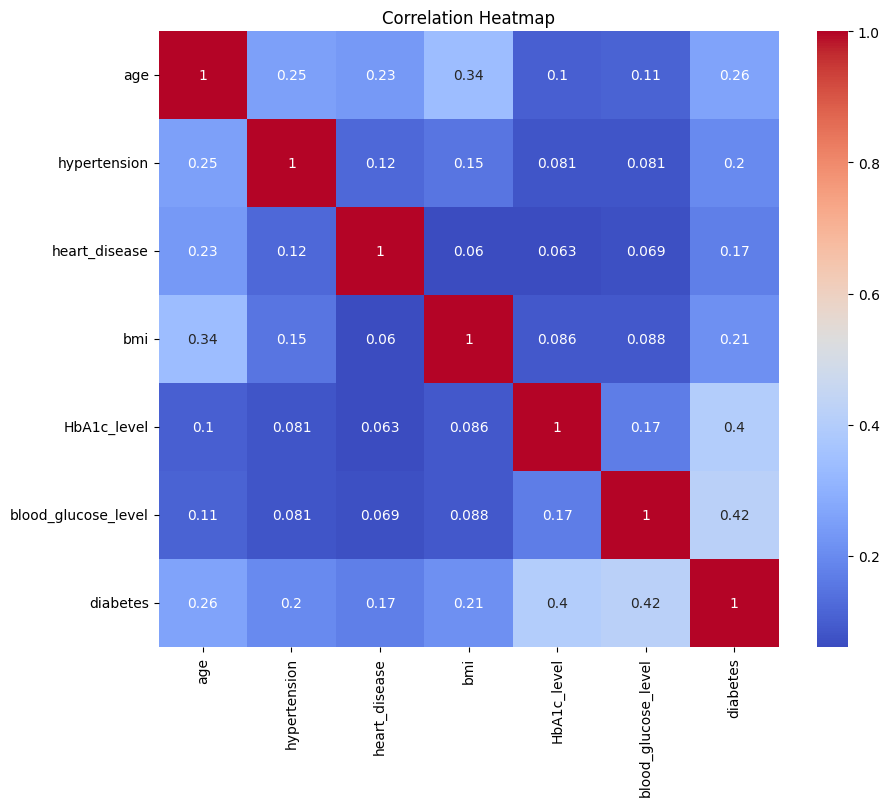

In [ ]:
# Correlation Heatmap
numerical_data = df.select_dtypes(include=[np.number])
plt.figure(figsize=(10, 8))
sns.heatmap(numerical_data.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

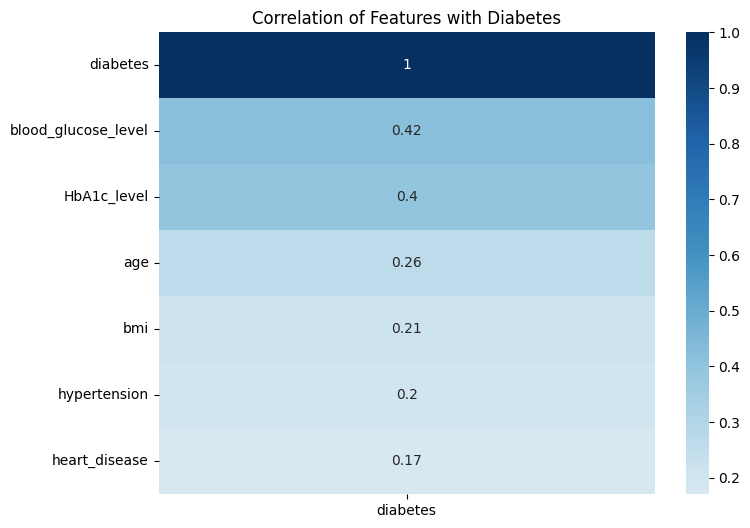

In [ ]:
# Correlation of each feature with the target (diabetes)
correlation_with_target = df.corr(numeric_only=True)['diabetes'].sort_values(ascending=False)

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_with_target.to_frame(), annot=True, cmap='RdBu', center=0)
plt.title('Correlation of Features with Diabetes')
plt.show()


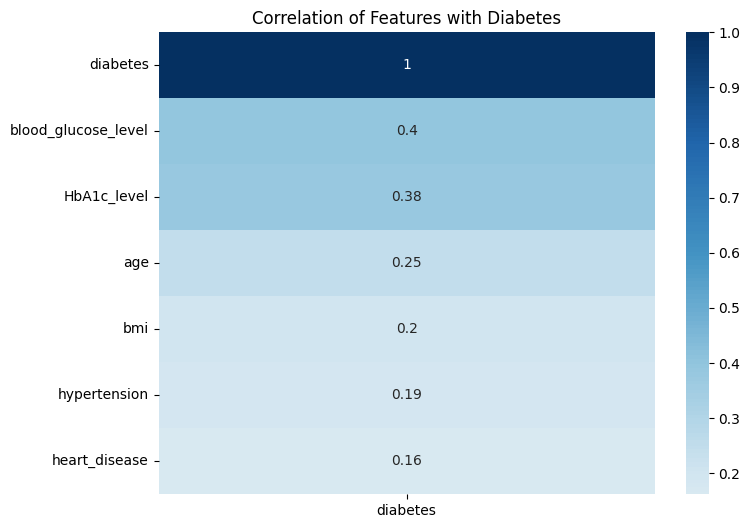

In [ ]:
# Drop rows with missing target
df = df.dropna(subset=['diabetes']).copy()

# Numerical columns: median imputation
for col in ['age', 'bmi', 'HbA1c_level', 'blood_glucose_level']:
    df[col] = df[col].fillna(df[col].median())



# Correlation with the target variable
correlation_with_target = df.corr(numeric_only=True)['diabetes'].sort_values(ascending=False)
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_with_target.to_frame(), annot=True, cmap='RdBu', center=0)
plt.title('Correlation of Features with Diabetes')
plt.show()


# Categorical: fill with defaults
df['smoking_history'] = df['smoking_history'].fillna('No Info')
df['gender'] = df['gender'].fillna('Unknown')
df['hypertension'] = df['hypertension'].fillna(0)
df['heart_disease'] = df['heart_disease'].fillna(0)


In [ ]:
# Encode gender
df['gender'] = df['gender'].map({'Male': 0, 'Female': 1, 'Other': 2, 'Unknown': 3})

# One-hot encoding
df = pd.get_dummies(df, columns=['smoking_history'], drop_first=True)


In [ ]:
# Feature-target split
X = df.drop('diabetes', axis=1)
y = df['diabetes']

# Standard scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X = pd.DataFrame(X_scaled, columns=X.columns)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)




In [ ]:


sm = SMOTE(random_state=42)
X_train, y_train = sm.fit_resample(X_train, y_train)


In [ ]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced'),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Decision Tree': DecisionTreeClassifier(),
    'Naive Bayes': GaussianNB(),
    'Neural Net': MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)
}

# Train all models
for name, model in models.items():
    model.fit(X_train, y_train)


Feature Importance (Logistic Regression):
                        Feature  Coefficient
5                   HbA1c_level     2.135422
6           blood_glucose_level     1.200738
1                           age     1.087019
4                           bmi     0.620190
2                  hypertension     0.201562
3                 heart_disease     0.175057
10        smoking_history_never     0.171546
7       smoking_history_current     0.153273
9        smoking_history_former     0.147365
11  smoking_history_not current     0.105306
8          smoking_history_ever     0.092602
0                        gender    -0.074443


<ipython-input-19-9feb2e5fc019>:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x='Absolute Coefficient', y='Feature', palette='viridis')


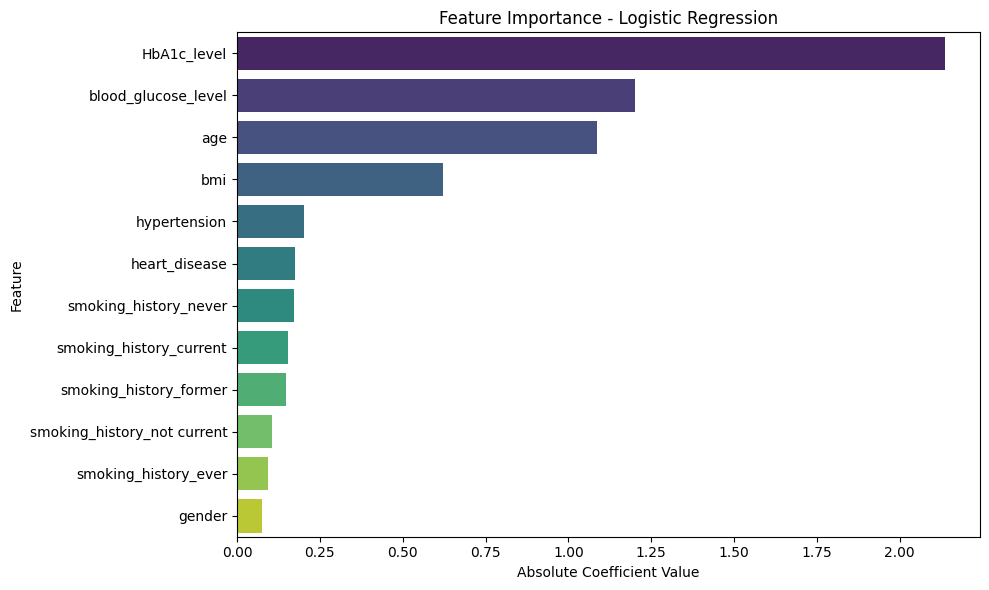

In [ ]:
# ----- Feature Importance for Logistic Regression -----

# Extract the logistic regression model
log_model = models['Logistic Regression']

# Get feature names and coefficients
feature_names = X.columns
coefficients = log_model.coef_[0]

# Create DataFrame of feature importances
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients,
    'Absolute Coefficient': np.abs(coefficients)
}).sort_values(by='Absolute Coefficient', ascending=False)

# Print ranked features
print("Feature Importance (Logistic Regression):")
print(importance_df[['Feature', 'Coefficient']])

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x='Absolute Coefficient', y='Feature', palette='viridis')
plt.title("Feature Importance - Logistic Regression")
plt.xlabel("Absolute Coefficient Value")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


In [ ]:
for name, model in models.items():
    print(f"\n{name}")
    y_pred = model.predict(X_test)
    print(classification_report(y_test, y_pred))



Logistic Regression
              precision    recall  f1-score   support

         0.0       0.98      0.87      0.92     16457
         1.0       0.37      0.85      0.52      1527

    accuracy                           0.87     17984
   macro avg       0.68      0.86      0.72     17984
weighted avg       0.93      0.87      0.89     17984


KNN
              precision    recall  f1-score   support

         0.0       0.98      0.91      0.94     16457
         1.0       0.44      0.77      0.56      1527

    accuracy                           0.90     17984
   macro avg       0.71      0.84      0.75     17984
weighted avg       0.93      0.90      0.91     17984


Decision Tree
              precision    recall  f1-score   support

         0.0       0.97      0.96      0.97     16457
         1.0       0.64      0.70      0.67      1527

    accuracy                           0.94     17984
   macro avg       0.80      0.83      0.82     17984
weighted avg       0.94      0.94

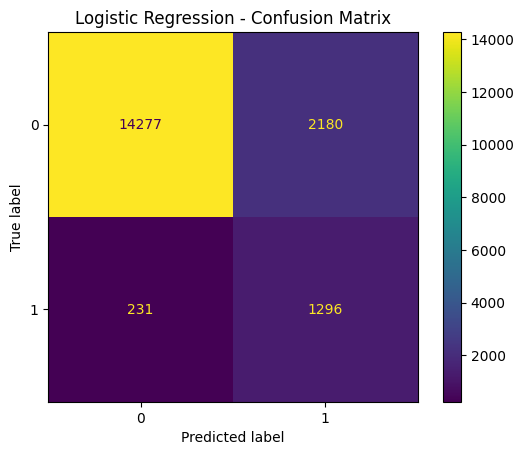

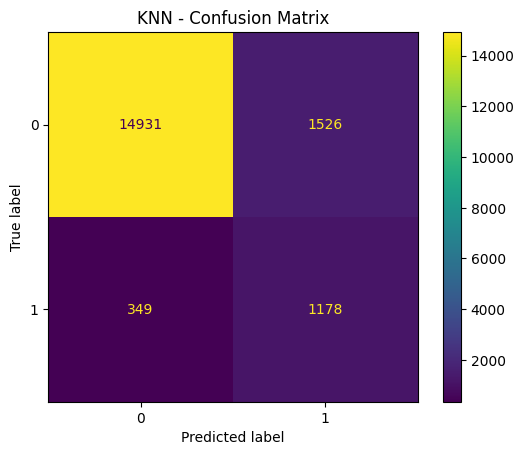

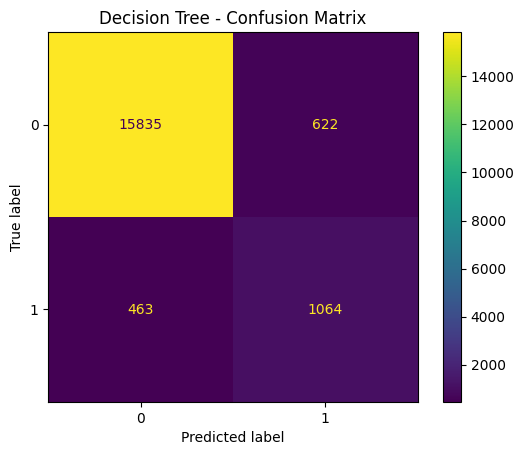

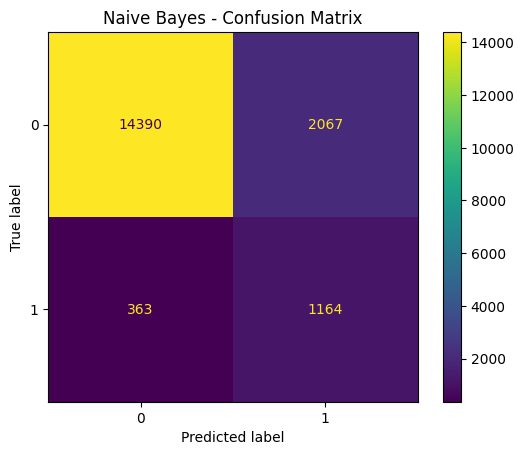

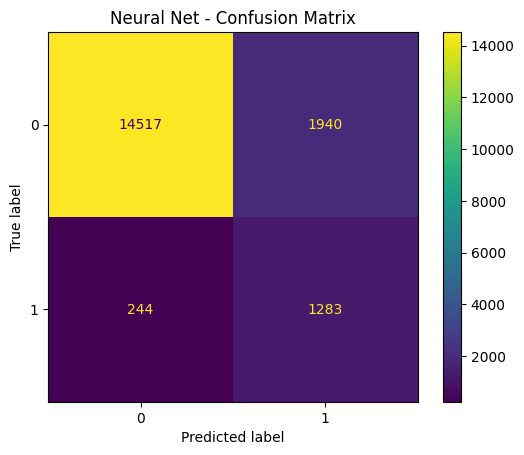

In [ ]:
for name, model in models.items():
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(f"{name} - Confusion Matrix")
    plt.show()


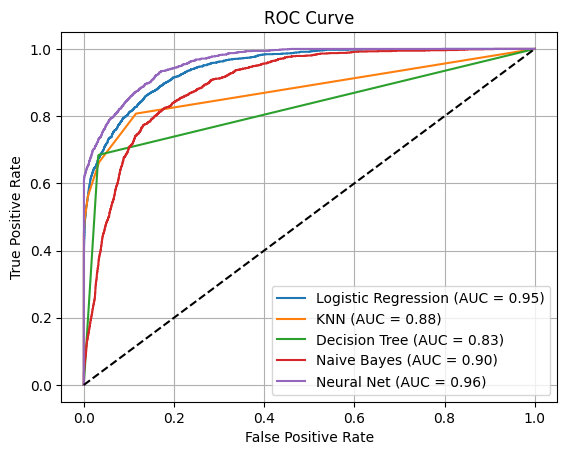

In [ ]:
for name, model in models.items():
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        y_prob = model.decision_function(X_test)
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc_score(y_test, y_prob):.2f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid()
plt.show()


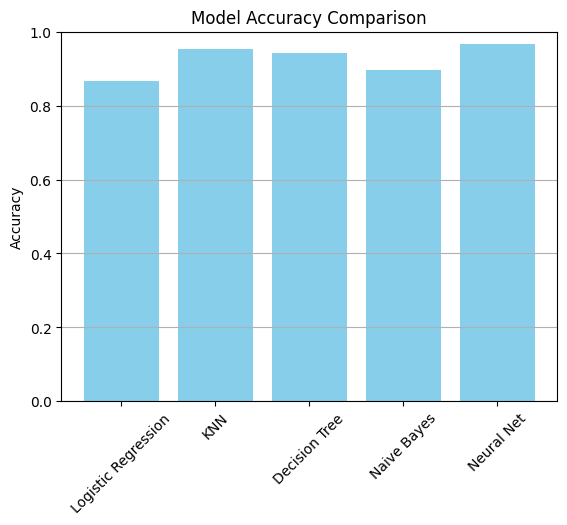

In [ ]:
accuracies = [accuracy_score(y_test, model.predict(X_test)) for model in models.values()]
plt.bar(models.keys(), accuracies, color='skyblue')
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.grid(axis='y')
plt.show()


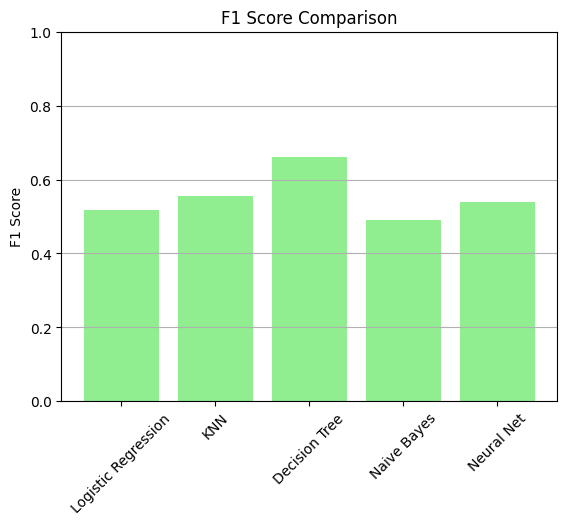

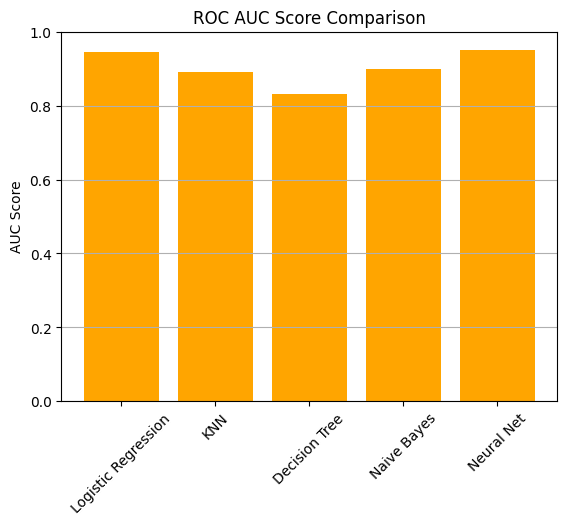

In [ ]:
# F1 Score Bar Plot
from sklearn.metrics import f1_score

f1s = [f1_score(y_test, model.predict(X_test)) for model in models.values()]
plt.bar(models.keys(), f1s, color='lightgreen')
plt.title("F1 Score Comparison")
plt.ylabel("F1 Score")
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.grid(axis='y')
plt.show()

# ROC AUC Bar Plot
from sklearn.metrics import roc_auc_score

aucs = [
    roc_auc_score(y_test, model.predict_proba(X_test)[:, 1]) if hasattr(model, 'predict_proba')
    else roc_auc_score(y_test, model.decision_function(X_test))
    for model in models.values()
]
plt.bar(models.keys(), aucs, color='orange')
plt.title("ROC AUC Score Comparison")
plt.ylabel("AUC Score")
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.grid(axis='y')
plt.show()
